<table align="left" width=100%>
    <tr>
        <td width="20%">
            <img src="Faculty.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                  <b> Faculty Notebook <br> (Session 3) </b><br>
                <font color="#21618C" size=4px>
                    <b> MNIST neural network - Hyperparameter Optimization using Tensorflow</b>
                </font>
            </div>
        </td>
    </tr>
</table>

### MNIST Dataset
The MNIST database contains 60,000 training images and 10,000 testing images taken from American Census Bureau employees and American high school students. The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. In fact, even Tensorflow and Keras allow us to import and download the MNIST dataset directly from their API.

In [2]:
import tensorflow as tf
import numpy as np
!pip install scikeras

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# un-comment this if executing locally - to download the mnsit dataset 
# import requests
# requests.packages.urllib3.disable_warnings()
# import ssl

# try:
#     _create_unverified_https_context = ssl._create_unverified_context
# except AttributeError:
#     # Legacy Python that doesn't verify HTTPS certificates by default
#     pass
# else:
#     # Handle target environment that doesn't support HTTPS verification
#     ssl._create_default_https_context = _create_unverified_https_context

In [3]:
#Load the MNIST digit datset
from tensorflow.keras.datasets import mnist
(xtrain,ytrain),(xtest,ytest)=mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [4]:
xtrain.shape # there are 60000 images of each 28 rows and 28 columns

(60000, 28, 28)

In [5]:
xtest.shape

(10000, 28, 28)

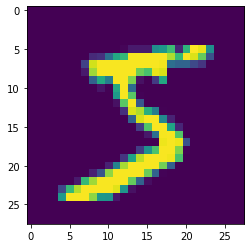

In [6]:
from matplotlib import pyplot as plt
plt.imshow(xtrain[0,:,:])

In [7]:
ytrain[0] # The output label for the image shown above

5

In [8]:
x_train=xtrain.reshape(60000,28*28) # reshaping images as one dimensional
x_test=xtest.reshape(10000,28*28)

In [9]:
x_train=x_train/255. # scaling the images
x_test=x_test/255.

In [10]:
y_train=tf.keras.utils.to_categorical(ytrain,num_classes=10) # Encoding the target levels
y_test=tf.keras.utils.to_categorical(ytest,num_classes=10) 

In [11]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

In [12]:
ytrain[0]

5

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers, optimizers

In [14]:
#Create the function to define a DNN model with dynamic iteration, learning_rate, 
#regularization penalty# neurons in the hidden layer for tuning
def train_and_test_model(itr,learning_rate,lamda):
    
    iterations=itr
    learning_rate=learning_rate
    hidden_nodes=256
    output_nodes=10
    
    model=Sequential()
    model.add(Dense(units=hidden_nodes,activation='relu',input_dim=784))
    model.add(Dense(units=hidden_nodes,activation='relu'))
    model.add(Dense(units=output_nodes,activation='softmax',kernel_regularizer=regularizers.l2(lamda)))
    
    sgd=optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',optimizer=sgd,metrics=['accuracy'])
    
    model.fit(x_train,y_train,epochs=iterations,batch_size=1000,verbose=0)
    [loss,score_train]=model.evaluate(x_train,y_train)
    [loss,score_test]=model.evaluate(x_test,y_test)
    
    return score_train,score_test  # returning both train and test scores

In [15]:
learning_rate=0.00001 # Choose very small value of learning rate
lamda=0
train_and_test_model(10,learning_rate,lamda) # Leading to vanishing gradiant problem
# loss is not changing in each iteration much and model accuracy is poor. 
#To understand it run with verbose =1 in the above function

313/313 [==============================] - 1s 4ms/step - loss: 2.3833 - accuracy: 0.0916


(0.0921500027179718, 0.09160000085830688)

In [16]:
learning_rate=0.001 # Increasing the learning_rate to 0.001 improving the performance slightly
lamda=0 # no regularization
train_and_test_model(10,learning_rate,lamda)

313/313 [==============================] - 1s 2ms/step - loss: 1.9614 - accuracy: 0.5561


(0.5425333380699158, 0.5561000108718872)

In [17]:
learning_rate=0.1# Increasing the learning_rate to 0.1 improving the performance above 90 percent
lamda=0
train_and_test_model(10,learning_rate,lamda)

313/313 [==============================] - 1s 3ms/step - loss: 0.2045 - accuracy: 0.9413


(0.9419500231742859, 0.9412999749183655)

In [18]:
learning_rate=1 # learning rate of 1 giving very good results for this datset [It may not be same for all the data]
lamda=0
train_and_test_model(10,learning_rate,lamda)

313/313 [==============================] - 1s 3ms/step - loss: 0.1406 - accuracy: 0.9562


(0.9615333080291748, 0.9562000036239624)

In [19]:
learning_rate=50   # Increasing the lr to 50 leading to Exploding Gradient. Loss going out of control
lamda=0
train_and_test_model(10,learning_rate,lamda)

313/313 [==============================] - 1s 3ms/step - loss: nan - accuracy: 0.0980


(0.09871666878461838, 0.09799999743700027)

In [20]:
learning_rate=0.0000001  # Vanishing Gradient
lamda=0
train_and_test_model(10,learning_rate,lamda)

313/313 [==============================] - 1s 2ms/step - loss: 2.3794 - accuracy: 0.0822


(0.08421666920185089, 0.08219999819993973)

In [21]:
learning_rate=1 
lamda=0.02 # Introduce small regularization, regularization will reduce overfitting, but bias error may slightly increase
train_and_test_model(10,learning_rate,lamda) # Less overfitting

313/313 [==============================] - 1s 3ms/step - loss: 0.3819 - accuracy: 0.9077


(0.9085000157356262, 0.9077000021934509)

In [ ]:
learning_rate=1 
lamda=1 
train_and_test_model(10,learning_rate,lamda) # Underfitting, penalty(lamda) of 1, reducing the performance greatly

313/313 [==============================] - 1s 3ms/step - loss: 26.0948 - accuracy: 0.1127


(0.1117333322763443, 0.11270000040531158)

In [ ]:
#Coarse tuning - Explore the model for wide span of learning rate and lamda(regularization penalty)
learning_rate=[0.0001,0.001,0.01,0.1,1,10,20,50]
lam=[0.0001,0.001,0.01,0.1,1,10,20,50]
for i,j in zip(learning_rate,lam):
    score=train_and_test_model(10,i,j)
    print('epocs:',10,'train_accuracy:',score[0],'test_accuracy:',score[1],'alpha:', i,'Regularization:',j)

313/313 [==============================] - 1s 2ms/step - loss: 2.2754 - accuracy: 0.1292
epocs: 10 train_accuracy: 0.1237500011920929 test_accuracy: 0.12919999659061432 alpha: 0.0001 Regularization: 0.0001
313/313 [==============================] - 1s 2ms/step - loss: 1.9770 - accuracy: 0.5621
epocs: 10 train_accuracy: 0.5579500198364258 test_accuracy: 0.5620999932289124 alpha: 0.001 Regularization: 0.001
313/313 [==============================] - 1s 3ms/step - loss: 0.7111 - accuracy: 0.8763
epocs: 10 train_accuracy: 0.8696333169937134 test_accuracy: 0.8762999773025513 alpha: 0.01 Regularization: 0.01
313/313 [==============================] - 1s 2ms/step - loss: 0.5332 - accuracy: 0.8900
epocs: 10 train_accuracy: 0.8858000040054321 test_accuracy: 0.8899999856948853 alpha: 0.1 Regularization: 0.1
313/313 [==============================] - 1s 2ms/step - loss: 26.0541 - accuracy: 0.1142
epocs: 10 train_accuracy: 0.11356666684150696 test_accuracy: 0.11420000344514847 alpha: 1 Regularizat

In [ ]:
#Another random way of doing coarse tuning
import math
for k in range(1,10):
    learning_rate = math.pow(10, np.random.uniform(-7.0, 3.0))
    Lambda = math.pow(10, np.random.uniform(-7,-2))
    best_acc = train_and_test_model(10, learning_rate, Lambda)
    print('k:',k,'epocs:',100,'accuracy:',best_acc,'alpha:', learning_rate,'Regularization:',Lambda)


313/313 [==============================] - 1s 3ms/step - loss: 2.4323 - accuracy: 0.1199
k: 1 epocs: 100 accuracy: (0.11991667002439499, 0.11990000307559967) alpha: 1.7119971859121204e-07 Regularization: 0.005771718064707286
313/313 [==============================] - 1s 3ms/step - loss: 0.8471 - accuracy: 0.8344
k: 2 epocs: 100 accuracy: (0.824833333492279, 0.8343999981880188) alpha: 0.0042797027259022374 Regularization: 2.174691108662937e-06
313/313 [==============================] - 1s 3ms/step - loss: 824574648241587688046592.0000 - accuracy: 0.0958
k: 3 epocs: 100 accuracy: (0.09863333404064178, 0.0957999974489212) alpha: 804.3982753486443 Regularization: 3.2476823596561417e-06
313/313 [==============================] - 1s 3ms/step - loss: nan - accuracy: 0.0980
k: 4 epocs: 100 accuracy: (0.09871666878461838, 0.09799999743700027) alpha: 549.5149105483523 Regularization: 3.776193658413011e-05
313/313 [==============================] - 1s 3ms/step - loss: nan - accuracy: 0.0980
k: 5 

In [ ]:
import math
math.pow(10,np.random.uniform(-7.0, 3.0))

0.005707576482474473

In [ ]:
#Create the function to define a DNN model with dynamic learning_rate, regularization penalty
         # neurons in the hidden layer,activation function and weight intitialization for tuning
def tune_model(learning_rate,activation, lamda,initializer,num_unit):
    model = Sequential()
    model.add(Dense(num_unit, kernel_initializer=initializer,activation=activation, input_dim=784))
    #model.add(Dropout(dropout_rate))
    model.add(Dense(num_unit, kernel_initializer=initializer,activation=activation))
    #model.add(Dropout(dropout_rate)) 
    model.add(Dense(10, activation='softmax',kernel_regularizer=regularizers.l2(lamda)))
    sgd = optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',optimizer=sgd,metrics=['accuracy'])
    return model

In [ ]:
#he_normal 
#std = sqrt(2/fan_in)
#fan_in= number of neurons in the hiddenlayer

In [ ]:
#Define hyper parameters values
batch_size = [20, 50, 100][:1]
epochs = [1, 20, 50][:1]
initializer = ['lecun_uniform', 'normal', 'he_normal', 'he_uniform'][:1]
learning_rate = [0.1, 0.001, 0.02][:1]
lamda = [0.001, 0.005, 0.01][:1]
num_unit = [256, 128][:1]
activation = ['relu', 'tanh', 'sigmoid', 'hard_sigmoid', 'linear'][:1]

In [ ]:
#create dictionary with hyper parameters
parameters = dict(batch_size = batch_size,
                  epochs = epochs,
                  learning_rate=learning_rate,
                  lamda = lamda,
                  num_unit = num_unit,
                  initializer = initializer,
                  activation = activation)

In [ ]:
parameters

{'batch_size': [20],
 'epochs': [1],
 'learning_rate': [0.1],
 'lamda': [0.001],
 'num_unit': [256],
 'initializer': ['lecun_uniform'],
 'activation': ['relu']}

In [ ]:
# Make this keras model compatible to sklearn to apply gridsearchCV
#model =tf.keras.wrappers.scikit_learn.KerasClassifier(build_fn=tune_model, verbose=0)
from scikeras.wrappers import KerasClassifier
model = KerasClassifier(model = tune_model, verbose=0, activation='relu',initializer='lecun_uniform',
                       lamda=0.001,learning_rate=0.1,num_unit=256)

In [ ]:
from sklearn.model_selection import GridSearchCV
models = GridSearchCV(estimator = model, param_grid=parameters, n_jobs=1)

In [ ]:
best_model = models.fit(x_train, y_train)
print('Best model :',best_model.best_params_)

Best model : {'activation': 'relu', 'batch_size': 20, 'epochs': 1, 'initializer': 'lecun_uniform', 'lamda': 0.001, 'learning_rate': 0.1, 'num_unit': 256}


In [ ]:
import pandas as pd
pd.DataFrame(best_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_batch_size,param_epochs,param_initializer,param_lamda,param_learning_rate,param_num_unit,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,10.183263,1.35178,1.29657,0.066222,relu,20,1,lecun_uniform,0.001,0.1,256,"{'activation': 'relu', 'batch_size': 20, 'epoc...",0.961,0.957167,0.960667,0.943167,0.95325,0.95505,0.006571,1


In [ ]:
# Run for all the combinations and take the best results interms of both bias and variance error